In [ ]:
#----input deployment locations
#site 1 deployment 1
deployment0101_lat = 14.616
deployment0101_lon = -17.631

#site 1, deployment 2
deployment0102_lat =14.615
deployment0102_lon =-17.630

#site 1, deployment 3
deployment0103_lat = 14.618
deployment0103_lon = -17.628

#site 1, deployment 4
deployment0104_lat = 14.618
deployment0104_lon = -17.628

#site 2, deployments 1 & 2
deployment020102_lat = 14.742
deployment020102_lon = -17.636

# Import packages

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# for adding projection to maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# for adding rectangle regions of interest to plots
import matplotlib.patches as patches

# Read metadata from NOAA OISST v2.1 from ERDDAP

In [2]:
# lazy load oisst data
url = 'https://comet.nefsc.noaa.gov/erddap/griddap/noaa_psl_2d74_d418_a6fb' # Sea Surface Tempearture, NOAA/NCEI Optimum Interpolation SST (OISST) AVHRR-only Analysis (V2.1), Global 0.25°, Monthly 1981-present
ds = xr.open_dataset(url)
print(f"Size in GB: {ds.nbytes / 1e9:.2f} GB")
ds.sizes
ds

Size in GB: 2.21 GB


<xarray.Dataset> Size: 2GB
Dimensions:    (time: 533, latitude: 720, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1981-09-01 1981-10-01 ... 2026-01-01
  * latitude   (latitude) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float32 6kB 0.125 0.375 0.625 ... 359.4 359.6 359.9
Data variables:
    sst        (time, latitude, longitude) float32 2GB ...
Attributes: (12/35)
    cdm_data_type:              Grid
    comment:                    Reynolds, et al.(2007) Daily High-Resolution-...
    Conventions:                CF-1.10, COARDS, ACDD-1.3
    creator_name:               NOAA/National Centers for Environmental Infor...
    creator_type:               group
    creator_url:                https://www.noaa.gov/
    ...                         ...
    testOutOfDate:              now-114days
    time_coverage_end:          2026-01-01T00:00:00Z
    time_coverage_start:        1981-09-01T00:00:00Z
    title:                      Satellite Sea Surface Tempearture | NOAA/NCEI...
    version:                    Version 2.1
    Westernmost_Easting:        0.125

In [ ]:
# load oisst data into memory and save as a netcdf file so it can be easily loaded into memory in the future
#ds.load() #load into RAM
#ds.to_netcdf("data/oisst_sst.nc") #write .nc file
#del ds #delete the varialbe

In [32]:
#file_path = "data/oisst_sst.nc" # load oisst_sst.nc data from local storage
#ds = xr.open_dataset(file_path) # Open the dataset
#ds # Print the summary to see dimensions, coordinates, and variables

<xarray.Dataset>
Dimensions:    (time: 532, latitude: 720, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 1981-09-01 1981-10-01 ... 2025-12-01
  * latitude   (latitude) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float32 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst        (time, latitude, longitude) float32 ...
Attributes: (12/35)
    cdm_data_type:              Grid
    comment:                    Reynolds, et al.(2007) Daily High-Resolution-...
    Conventions:                CF-1.10, COARDS, ACDD-1.3
    creator_name:               NOAA/National Centers for Environmental Infor...
    creator_type:               group
    creator_url:                https://www.noaa.gov/
    ...                         ...
    testOutOfDate:              now-114days
    time_coverage_end:          2025-12-01T00:00:00Z
    time_coverage_start:        1981-09-01T00:00:00Z
    title:                      Satellite Sea Surface Tempearture | NOAA/NCEI...
    version:                    Version 2.1
    Westernmost_Easting:        0.125

## Change longitudes to -180 to +180 so that you can plot across the prime meridian

### Plot one time slice to confirm that longitudes have been converted

See https://docs.xarray.dev/en/stable/generated/xarray.Dataset.assign_coords.html

In [3]:
ds = ds.assign_coords(longitude = ((ds.longitude + 180) % 360) - 180)
ds = ds.sortby('longitude') # don't forget to sort!!

In [4]:
colormap = 'RdBu_r'

date_range = ("1982-01-01", "2020-12-01")

# crop the globe down to this box to save memory
lat_min = -10
lat_max = 30
lon_min = -45
lon_max = 15

ds = ds['sst'].sel(latitude=slice(lat_min, lat_max), longitude=slice(lon_min, lon_max))

In [5]:
ds.load() #load this subset into memory for much faster computing on the NMFS jupyterhub

<xarray.DataArray 'sst' (time: 533, latitude: 160, longitude: 240)> Size: 82MB
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [26.816332, 26.760666, 26.739   , ...,       nan,       nan,
               nan],
        [26.872334, 26.8     , 26.682999, ...,       nan,       nan,
               nan],
        [26.913332, 26.872334, 26.714333, ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
...
        [24.260645, 24.370321, 24.404194, ...,       nan,       nan,
               nan],
        [24.199999, 24.31645 , 24.359032, ...,       nan,       nan,
               nan],
        [24.060322, 24.175161, 24.24258 , ...,       nan,       nan,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [23.229033, 23.244516, 23.254192, ...,       nan,       nan,
               nan],
        [23.132902, 23.122902, 23.11129 , ...,       nan,       nan,
               nan],
        [22.715483, 22.695807, 22.696451, ...,       nan,       nan,
               nan]]], shape=(533, 160, 240), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1981-09-01 1981-10-01 ... 2026-01-01
  * latitude   (latitude) float32 640B -9.875 -9.625 -9.375 ... 29.62 29.88
  * longitude  (longitude) float32 960B -44.88 -44.62 -44.38 ... 14.62 14.88
Attributes: (12/13)
    actual_range:     [-1.8  32.14]
    colorBarMaximum:  32.0
    colorBarMinimum:  0.0
    ioos_category:    Temperature
    level_desc:       Surface
    long_name:        Monthly Mean of Sea Surface Temperature
    ...               ...
    precision:        2.0
    standard_name:    sea_surface_temperature
    statistic:        Monthly Mean
    units:            degree_C
    valid_range:      [-3. 45.]
    var_desc:         Sea Surface Temperature

In [6]:
clim_spat = ds.groupby("time.month").mean("time") #compute monthly climatology
anom_spat = ds.groupby("time.month") - clim_spat #compute monthly anomaly

In [7]:
# set limits for nothern and southern hemisphere figures

# northern hemisphere limits
lat_min_NH = 0
lat_max_NH = 30
lon_min_NH = -45
lon_max_NH = 0
ds_NH = ds.sel(latitude=slice(lat_min_NH, lat_max_NH), longitude=slice(lon_min_NH, lon_max_NH))

# southern hemisphere limits
lat_min_SH = -10
lat_max_SH = 20
lon_min_SH = -30
lon_max_SH = 15
ds_SH = ds.sel(latitude=slice(lat_min_SH, lat_max_SH), longitude=slice(lon_min_SH, lon_max_SH))

In [8]:
# compute monthly climatologies for NH and SH regions
# clim_spat_NH = ds_NH.groupby("time.month").mean("time")
# clim_spat_SH = ds_SH.groupby("time.month").mean("time")

#clim_spat_NH.plot(x='longitude', y='latitude', col="month", col_wrap=4, cmap = colormap, vmin = 20, vmax = 30);
#clim_spat_SH.plot(x='longitude', y='latitude', col="month", col_wrap=4, cmap = colormap, vmin = 20, vmax = 30);

In [9]:
# compute monthly anomalies for NH and SH regions
# anom_spat_NH = ds_NH.groupby("time.month") - clim_spat
# anom_spat_SH = ds_SH.groupby("time.month") - clim_spat

In [8]:
# define boxes that may be plotted on top of figures

#Dakar (region around recorders)
rec_lon_min = -20
rec_lon_max = -15
rec_lat_min = 12 
rec_lat_max = 17
rec_box = [rec_lon_min, rec_lon_max, rec_lat_min, rec_lat_max]

#Cape Verde Islands box
cvi_lon_min = -27
cvi_lon_max = -21
cvi_lat_min = 14
cvi_lat_max = 18
cvi_box = [cvi_lon_min, cvi_lon_max, cvi_lat_min, cvi_lat_max]

# Gulf of Guinea
gog_lon_min = 5.42
gog_lon_max = 10.67
gog_lat_min = -4.33
gog_lat_max = 2.12
gog_box = [gog_lon_min, gog_lon_max, gog_lat_min, gog_lat_max]

In [12]:
# specify year-month periods for 2x5 panel figures for NH and SH

SH_times = ["2021-06-01", "2021-07-01", "2021-08-01", "2021-09-01", "2021-10-01", 
                           "2022-06-01", "2022-07-01", "2022-08-01", "2022-09-01", "2022-10-01"]

NH_times = ["2022-01-01", "2022-02-01", "2022-03-01", "2022-04-01", "2022-05-01", 
                           "2023-01-01", "2023-02-01", "2023-03-01", "2023-04-01", "2023-05-01"]

SH_NH_times = ["2021-06-01", "2021-07-01", "2021-08-01", "2021-09-01", "2021-10-01", 
               "2022-01-01", "2022-02-01", "2022-03-01", "2022-04-01", "2022-05-01",            
               "2022-06-01", "2022-07-01", "2022-08-01", "2022-09-01", "2022-10-01",
                "2023-01-01", "2023-02-01", "2023-03-01", "2023-04-01", "2023-05-01"]

dat_anom_SH = anom_spat.sel(latitude=slice(lat_min_SH, lat_max_SH), longitude=slice(lon_min_SH, lon_max_SH), time=(SH_times))
dat_anom_NH = anom_spat.sel(latitude=slice(lat_min_NH, lat_max_NH), longitude=slice(lon_min_NH, lon_max_NH), time=(NH_times))

# create a dataset to display boreal winter using the southern hemisphere region, so that we have an apples-to-apples comparision
#    use NH_times (boreal winter)
#    use SH region (includes GoG)
dat_anom_SH_boreal = anom_spat.sel(latitude=slice(lat_min_SH, lat_max_SH), longitude=slice(lon_min_SH, lon_max_SH), time=(NH_times))

# examine max and min values for within the above temporal subsets of anomalies in order to make a plot with appropriate color-limits
print(dat_anom_SH.min().item())
print(dat_anom_SH.max().item())

print(dat_anom_NH.min().item())
print(dat_anom_NH.max().item())

-1.460245132446289
3.016613006591797
-2.4430274963378906
3.576749801635742


In [13]:
# function to draw boxes as needed in the plotting function below
def drawBox(lon_start, lon_end, lat_start, lat_end):

    width = lon_end - lon_start
    height = lat_end - lat_start

    # --- 4. Create and Add the Rectangle Patch ---
    rect = patches.Rectangle(
        (lon_start, lat_start),  # (x, y) - bottom-left corner
        width,                  # width
        height,                 # height
        linewidth=1,            # line thickness
        edgecolor='black',        # border color
        facecolor='none',       # no fill
        linestyle='-'          # dashed line style
    )

    return rect

In [16]:
# function to produce figures
def TwoByFive(dat, meta_title, box1, box2, box3, fig_name, cbar_lims, boxes):
    # boxes == 'all' puts box regions in all panels of the figure
    # boxes == 'one' puts box regions only in first panel of the figure
    
    # --- 2. Setup Multi-Panel Figure ---
    # Define the 5 time slices to plot (e.g., the first 5 months)
    time_slices = dat['time']
    N_PLOTS = len(time_slices)
    time_slices
    
    # Define the projection (PlateCarree is WGS84, good for global views)
    map_proj = ccrs.PlateCarree(central_longitude=0) 
    
    # Create the figure: 2 row, 5 columns
    fig, axes = plt.subplots(
        nrows=2,
        ncols=5, #N_PLOTS,
        figsize=(18, 5), # Total figure size (wide)
        subplot_kw={'projection': map_proj} # Apply the map projection to all subplots
    )

    # Determine global min/max SST for a consistent color scale across all panels
    #vmin = dat.min().item()
    #vmax = dat.max().item()
    vmin = cbar_lims[0]
    vmax = cbar_lims[1]
    
    # --- 3. Iterate and Plot ---
    for i, ax in enumerate(axes.flat):
        current_time = time_slices[i]
        sst_panel = dat.sel(time=current_time)
        
        # Plot the data using pcolormesh
        plot = sst_panel.plot.pcolormesh(
            ax=ax,
            transform=ccrs.PlateCarree(), # Data CRS is WGS84
            x='longitude',
            y='latitude',
            cmap = colormap, #cmap='coolwarm',
            vmin=vmin, # Use consistent limits
            vmax=vmax,
            add_colorbar=False, # We will add a single colorbar later
            #xticks=np.round(np.arange(dat.longitude.min(), dat.longitude.max(), 5)),
            #yticks=np.round(np.arange(dat.latitude.min(), dat.latitude.max(), 5))        
        )

        ax.coastlines(resolution='50m', color='black', linewidth=0.5)
        ax.add_feature(cfeature.LAND, facecolor='grey')   # Fill land with grey
        #ax.set_global() #this forces the plot to show the whole earth
    
        # Add title with the time stamp
        ax.set_title(current_time.dt.strftime('%Y-%m').item(), fontsize=12)

        
        if boxes == 'one': # to place boxes only in the first panel, use this:      
            if i == 0 and box1 != None:
                #rect = drawBox(lon_start, lon_end, lat_start, lat_end)
                rect = drawBox(box1[0], box1[1], box1[2], box1[3])
                ax.add_patch(rect)
            if i == 0 and box2 != None:
                rect = drawBox(box2[0], box2[1], box2[2], box2[3])
                ax.add_patch(rect)
            if i == 0 and box3 != None:
                rect = drawBox(box3[0], box3[1], box3[2], box3[3])
                ax.add_patch(rect)
        elif boxes == 'all': # to place boxes in every panel, use this:
            if box1 != None:
                #rect = drawBox(lon_start, lon_end, lat_start, lat_end)
                rect = drawBox(box1[0], box1[1], box1[2], box1[3])
                ax.add_patch(rect)
            if box2 != None:
                rect = drawBox(box2[0], box2[1], box2[2], box2[3])
                ax.add_patch(rect)
            if box3 != None:
                rect = drawBox(box3[0], box3[1], box3[2], box3[3])
                ax.add_patch(rect)
            
        # Optional: Add gridlines (only for the first panel to save space/cleanliness)
        if i == 0:
            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
            gl.top_labels = False
            gl.right_labels = False
            gl.bottom_labels = False
        elif i == 5:
            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
            gl.top_labels = False
            gl.right_labels = False
            gl.bottom_labels = True
        elif i >=6 and i <=10:
            gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
            gl.top_labels = False
            gl.right_labels = False
            gl.left_labels = False
            gl.bottom_labels = True
        else:        
            # Hide axis labels for subsequent panels for a cleaner look
            gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
            ax.set_ylabel('') # xarray often adds 'latitude', this removes it

    # --- 4. Add a Single Colorbar and Final Touches ---

    # Use the plot object from the last iteration to create a single colorbar
    #cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5]) # [left, bottom, width, height]
    cbar_ax = fig.add_axes([0.81, 0.25, 0.01, 0.5])
    cbar = fig.colorbar(
        plot,
        cax=cbar_ax,
        orientation='vertical',
        #label=f'SST ({dat.units})',
        label=f'SST ($^\circ$C)',
        extend='both' # Extends colorbar if data is outside vmin/vmax
    )
    
    # Adjust layout to prevent overlap and make room for the colorbar
    #plt.suptitle(meta_title, fontsize=16, y=1.3)
    #plt.tight_layout(rect=[0, 0, 0.9, 0]) # Adjust space for the main title and colorbar
    plt.tight_layout(rect=[.1, .05, 0.81, .94])
    plt.suptitle(meta_title, fontsize=16, y=1)
    #plt.show()
    plt.savefig(fig_name, dpi=300, bbox_inches='tight')

<>:111: SyntaxWarning: invalid escape sequence '\c'
<>:111: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_112/3762956624.py:111: SyntaxWarning: invalid escape sequence '\c'
  label=f'SST ($^\circ$C)',


/tmp/ipykernel_112/3762956624.py:118: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[.1, .05, 0.81, .94])


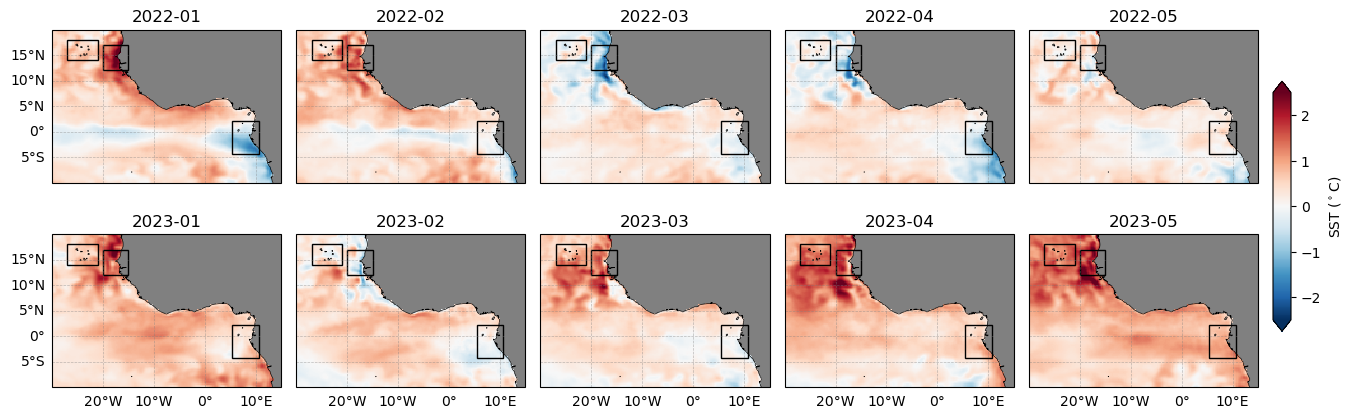

In [17]:
TwoByFive(dat_anom_SH_boreal, "", 
          gog_box, rec_box, cvi_box, "FigureX_borealWinter_SHregion.png", [-2.5, 2.5], 'all')

/tmp/ipykernel_109/1817525212.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[.1, .05, 0.81, .94])


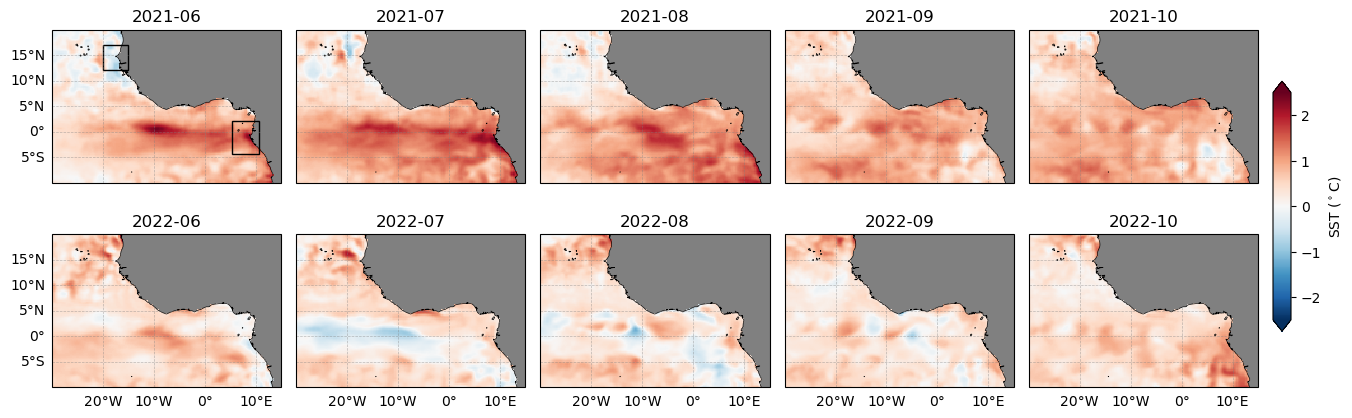

In [17]:
TwoByFive(dat_anom_SH, "", 
          gog_box, rec_box, None, "Figure6_SH_winter.png", [-2.5, 2.5])

/tmp/ipykernel_109/1817525212.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[.1, .05, 0.81, .94])


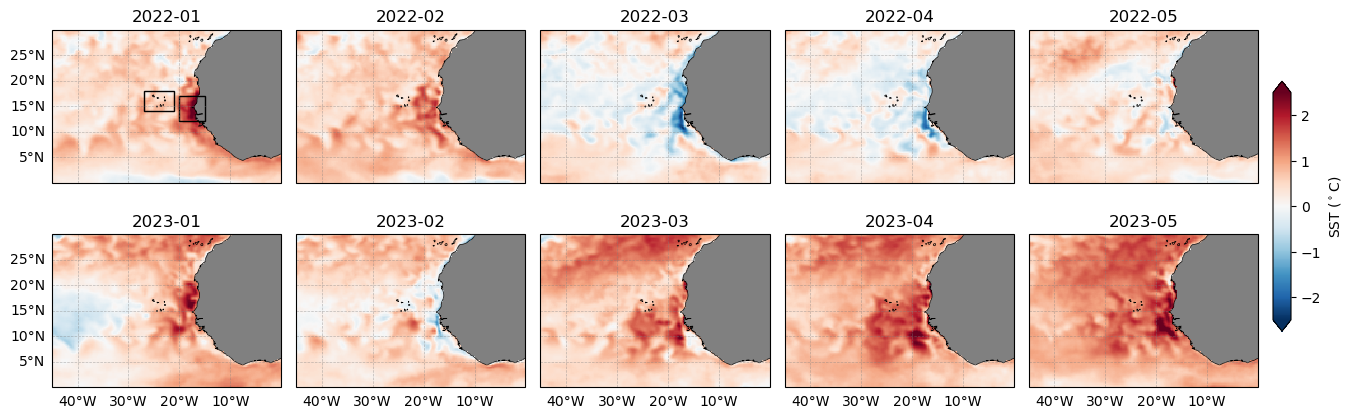

In [16]:
TwoByFive(dat_anom_NH, "", 
          rec_box, cvi_box, None, "Figure8_NH_winter.png", [-2.5, 2.5])

In [ ]:
#csv table with anomaly, climatology, sst deg C
# DNI data download and look at the months to see 
# look up figure specifications and produce final figures using -2.5 to +2.5

In [26]:
anom_gog = anom_spat.sel(latitude=slice(gog_lat_min, gog_lat_max), longitude=slice(gog_lon_min, gog_lon_max), 
                         time=(SH_NH_times))
anom_rec = anom_spat.sel(latitude=slice(rec_lat_min, rec_lat_max), longitude=slice(rec_lon_min, rec_lon_max), 
                         time=(SH_NH_times))
anom_cvi = anom_spat.sel(latitude=slice(cvi_lat_min, cvi_lat_max), longitude=slice(cvi_lon_min, cvi_lon_max), 
                         time=(SH_NH_times))

anom_gog_mean = anom_spat.sel(latitude=slice(gog_lat_min, gog_lat_max), longitude=slice(gog_lon_min, gog_lon_max), 
                              time=(SH_NH_times)).mean(dim = ['latitude','longitude'])
anom_rec_mean = anom_spat.sel(latitude=slice(rec_lat_min, rec_lat_max), longitude=slice(rec_lon_min, rec_lon_max), 
                              time=(SH_NH_times)).mean(dim = ['latitude','longitude'])
anom_cvi_mean = anom_spat.sel(latitude=slice(cvi_lat_min, cvi_lat_max), longitude=slice(cvi_lon_min, cvi_lon_max),
                              time=(SH_NH_times)).mean(dim = ['latitude','longitude'])

In [30]:
df_anom = xr.Dataset({
    # Drop 'month' so they align and 'month' column is removed.
    'anom_gog': anom_gog_mean.drop_vars('month'),
    'anom_rec': anom_rec_mean.drop_vars('month'),
    'anom_cvi': anom_cvi_mean.drop_vars('month')
}).to_dataframe()

df_anom

,anom_gog,anom_rec,anom_cvi
time,,,
2021-06-01,1.274521,-0.243290,0.115450
2021-07-01,1.688143,0.028437,0.353823
2021-08-01,1.285354,0.110863,0.218072
2021-09-01,0.615300,0.242928,0.473753
2021-10-01,0.513144,0.606298,0.512230
2022-01-01,-0.807294,1.887533,0.587090
2022-02-01,0.061548,1.324208,0.686050
2022-03-01,-0.083635,-0.931525,0.030515
2022-04-01,-0.467712,-0.592359,0.057151


In [31]:
sst_gog = ds.sel(latitude=slice(gog_lat_min, gog_lat_max), longitude=slice(gog_lon_min, gog_lon_max), 
                         time=(SH_NH_times))
sst_rec = ds.sel(latitude=slice(rec_lat_min, rec_lat_max), longitude=slice(rec_lon_min, rec_lon_max), 
                         time=(SH_NH_times))
sst_cvi = ds.sel(latitude=slice(cvi_lat_min, cvi_lat_max), longitude=slice(cvi_lon_min, cvi_lon_max), 
                         time=(SH_NH_times))

sst_gog_mean = ds.sel(latitude=slice(gog_lat_min, gog_lat_max), longitude=slice(gog_lon_min, gog_lon_max), 
                         time=(SH_NH_times)).mean(dim = ['latitude','longitude'])
sst_rec_mean = ds.sel(latitude=slice(rec_lat_min, rec_lat_max), longitude=slice(rec_lon_min, rec_lon_max), 
                         time=(SH_NH_times)).mean(dim = ['latitude','longitude'])
sst_cvi_mean = ds.sel(latitude=slice(cvi_lat_min, cvi_lat_max), longitude=slice(cvi_lon_min, cvi_lon_max), 
                         time=(SH_NH_times)).mean(dim = ['latitude','longitude'])

df_sst = xr.Dataset({
    'sst_gog': sst_gog_mean,
    'sst_rec': sst_rec_mean,
    'sst_cvi': sst_cvi_mean
})

# 2. Convert the entire Dataset to a DataFrame
df_sst = df_sst.to_dataframe()
df_sst

,sst_gog,sst_rec,sst_cvi
time,,,
2021-06-01,26.726061,24.830683,23.818359
2021-07-01,25.986172,26.805475,25.251749
2021-08-01,25.644968,27.694368,26.494101
2021-09-01,25.833414,28.217796,27.377813
2021-10-01,26.755054,28.824110,27.440207
2022-01-01,27.195580,24.160772,23.850807
2022-02-01,28.652470,22.395063,23.179811
2022-03-01,28.789469,20.032103,22.512650
2022-04-01,28.129236,20.901897,22.869591


In [33]:
df_anom_sst = xr.Dataset({
    'sst_gog': sst_gog_mean,
    'sst_rec': sst_rec_mean,
    'sst_cvi': sst_cvi_mean,
    # Drop 'month' so they align and 'month' column is removed.
    'anom_gog': anom_gog_mean.drop_vars('month'),
    'anom_rec': anom_rec_mean.drop_vars('month'),
    'anom_cvi': anom_cvi_mean.drop_vars('month')
}).to_dataframe()

df_anom_sst.to_csv('df_anom_sst.csv')
df_anom_sst

,sst_gog,sst_rec,sst_cvi,anom_gog,anom_rec,anom_cvi
time,,,,,,
2021-06-01,26.726061,24.830683,23.818359,1.274521,-0.243290,0.115450
2021-07-01,25.986172,26.805475,25.251749,1.688143,0.028437,0.353823
2021-08-01,25.644968,27.694368,26.494101,1.285354,0.110863,0.218072
2021-09-01,25.833414,28.217796,27.377813,0.615300,0.242928,0.473753
2021-10-01,26.755054,28.824110,27.440207,0.513144,0.606298,0.512230
2022-01-01,27.195580,24.160772,23.850807,-0.807294,1.887533,0.587090
2022-02-01,28.652470,22.395063,23.179811,0.061548,1.324208,0.686050
2022-03-01,28.789469,20.032103,22.512650,-0.083635,-0.931525,0.030515
2022-04-01,28.129236,20.901897,22.869591,-0.467712,-0.592359,0.057151


In [34]:
SH_months = [6, 7, 8, 9, 10]
NH_months = [1, 2, 3, 4, 5]
SH_NH_months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

clim_gog = clim_spat.sel(month = SH_NH_months, 
                         latitude=slice(gog_lat_min, gog_lat_max), longitude=slice(gog_lon_min, gog_lon_max))

clim_rec = clim_spat.sel(month = SH_NH_months, 
                         latitude=slice(rec_lat_min, rec_lat_max), longitude=slice(rec_lon_min, rec_lon_max))

clim_cvi = clim_spat.sel(month = SH_NH_months, 
                         latitude=slice(cvi_lat_min, cvi_lat_max), longitude=slice(cvi_lon_min, cvi_lon_max))

clim_gog_sst = clim_spat.sel(month = SH_NH_months, 
                         latitude=slice(gog_lat_min, gog_lat_max), 
                             longitude=slice(gog_lon_min, gog_lon_max)).mean(dim = ['latitude','longitude'])
clim_rec_sst = clim_spat.sel(month = SH_NH_months, 
                         latitude=slice(rec_lat_min, rec_lat_max), 
                             longitude=slice(rec_lon_min, rec_lon_max)).mean(dim = ['latitude','longitude'])
clim_cvi_sst = clim_spat.sel(month = SH_NH_months, 
                         latitude=slice(cvi_lat_min, cvi_lat_max), 
                             longitude=slice(cvi_lon_min, cvi_lon_max)).mean(dim = ['latitude','longitude'])

df_clim = xr.Dataset({
    'clim_gog': clim_gog_sst,
    'clim_rec': clim_rec_sst,
    'clim_cvi': clim_cvi_sst
})

# 2. Convert the entire Dataset to a DataFrame
df_clim = df_clim.to_dataframe()
df_clim.to_csv('df_clim.csv')
df_clim

,clim_gog,clim_rec,clim_cvi
month,,,
1,28.002872,22.273239,23.263718
2,28.590923,21.070854,22.493761
3,28.873104,20.963627,22.482132
4,28.596951,21.494257,22.812439
5,27.474714,22.808064,23.136909
6,25.451542,25.073973,23.702909
7,24.298031,26.777039,24.897926
8,24.359613,27.583506,26.276026
9,25.218117,27.974867,26.904062


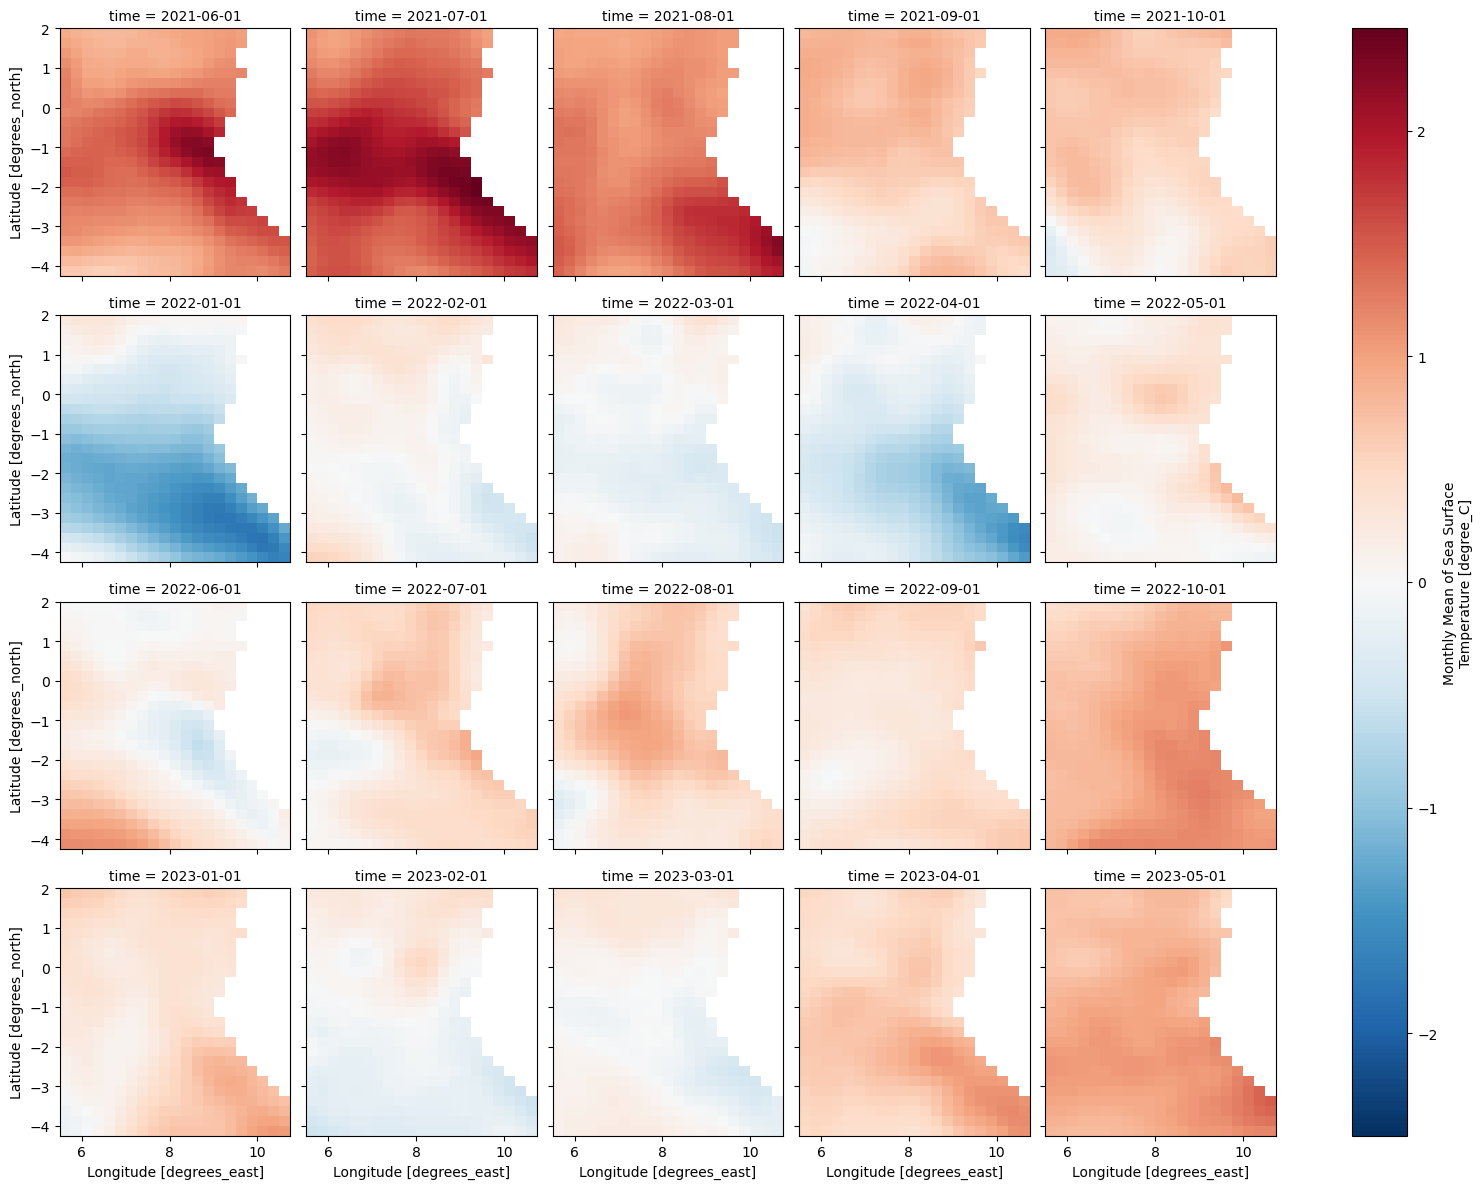

In [35]:
anom_gog.sel().plot(x = "longitude", y = "latitude", col = "time", col_wrap=5)

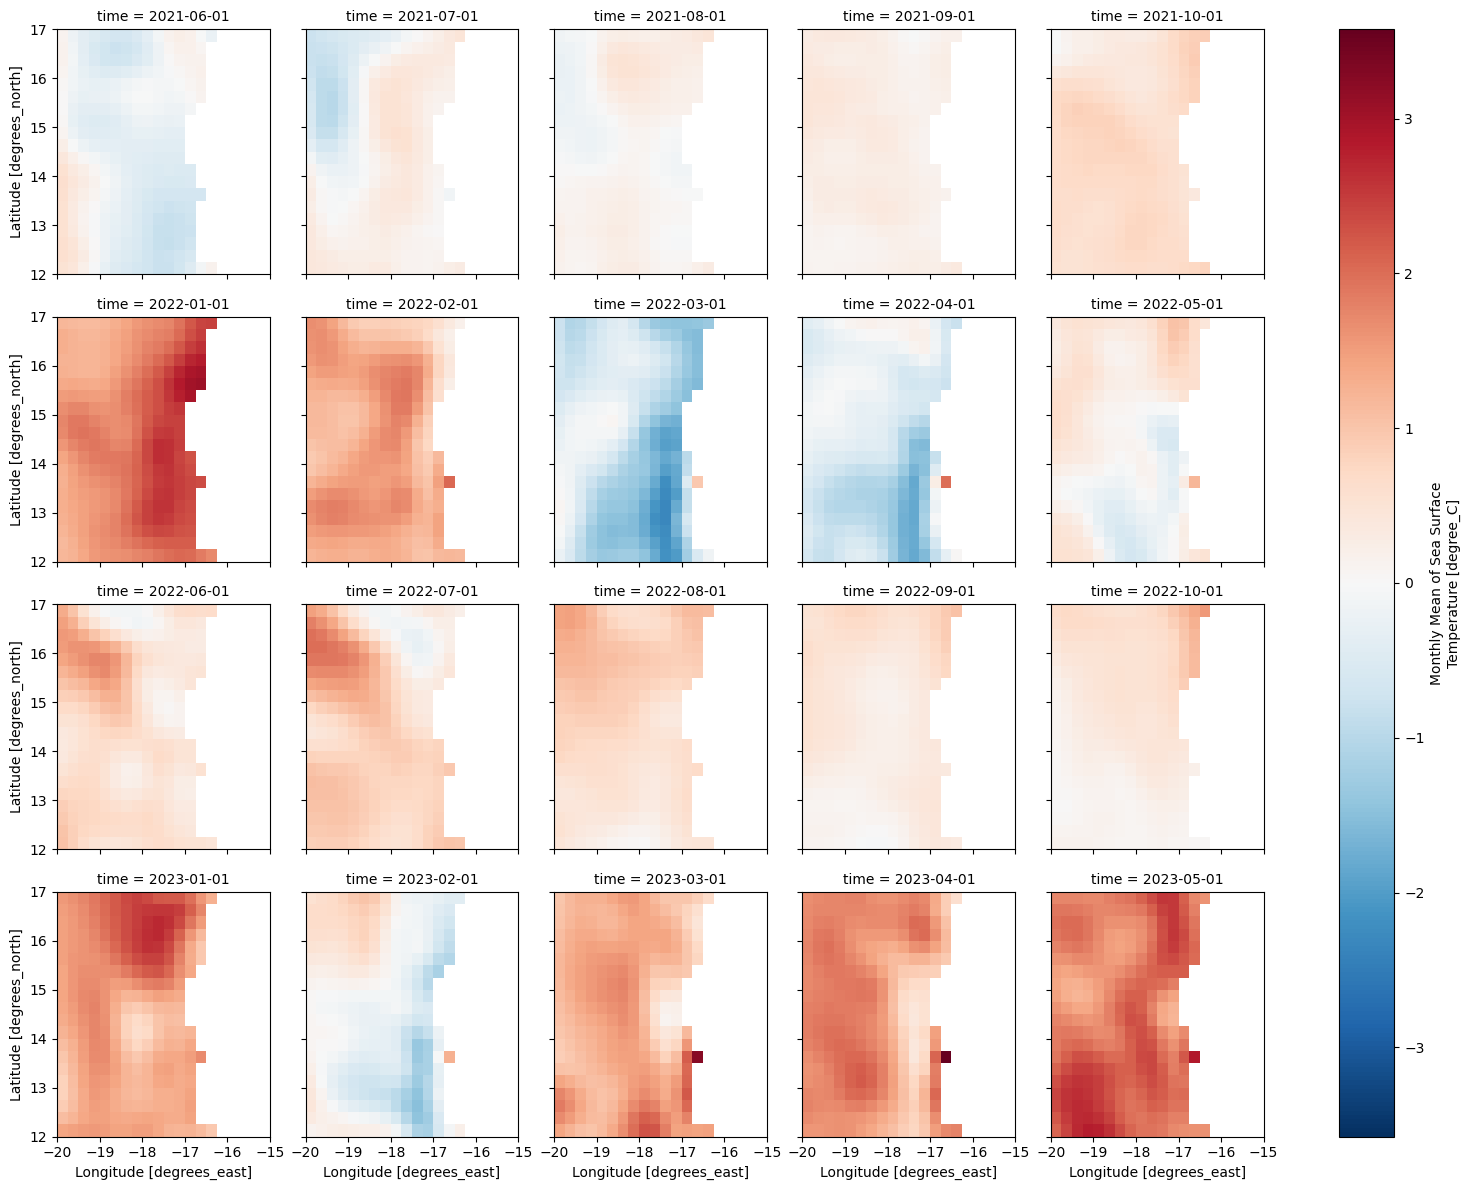

In [36]:
anom_rec.sel().plot(x = "longitude", y = "latitude", col = "time", col_wrap=5)

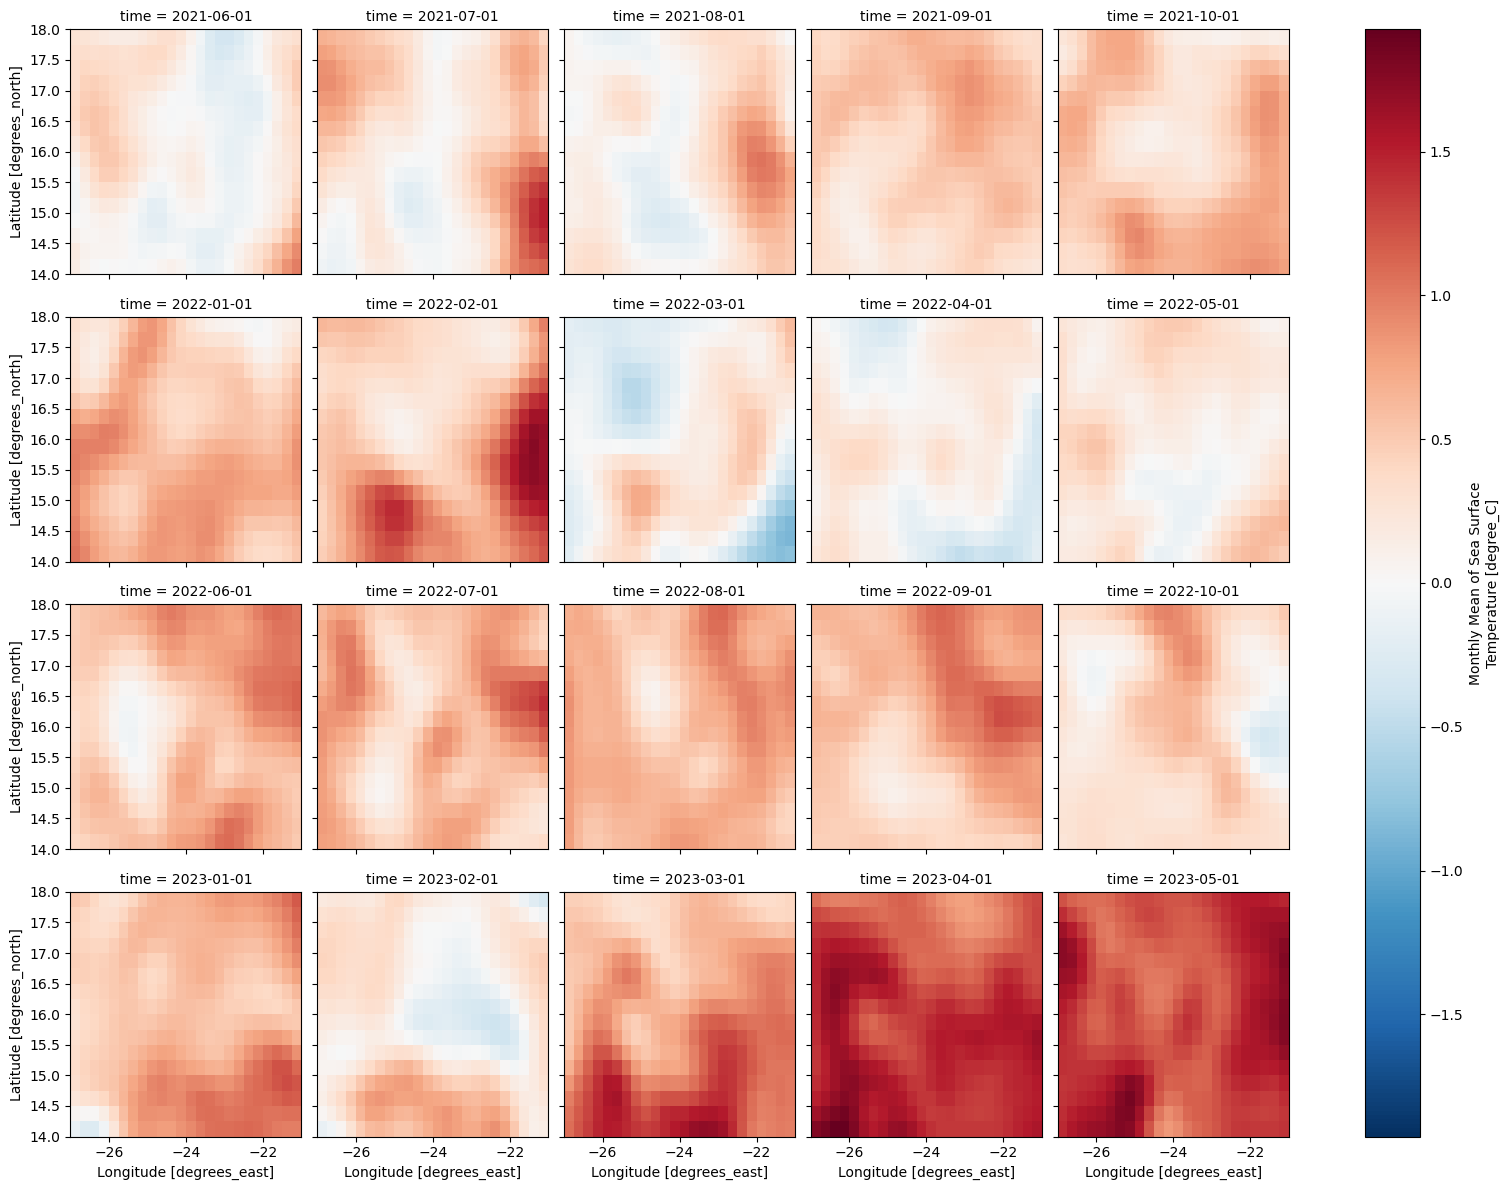

In [37]:
anom_cvi.sel().plot(x = "longitude", y = "latitude", col = "time", col_wrap=5)

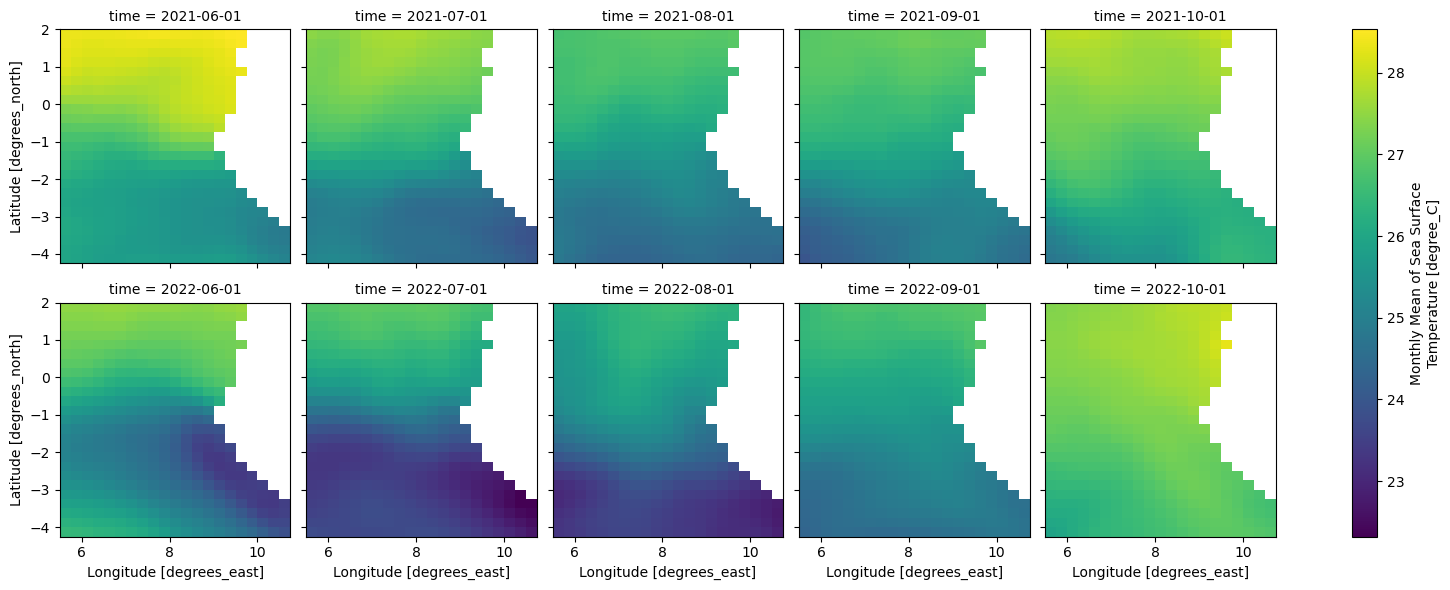

In [38]:
sst_gog.sel(time = SH_times).plot(x = "longitude", y = "latitude", col = "time", col_wrap=5)

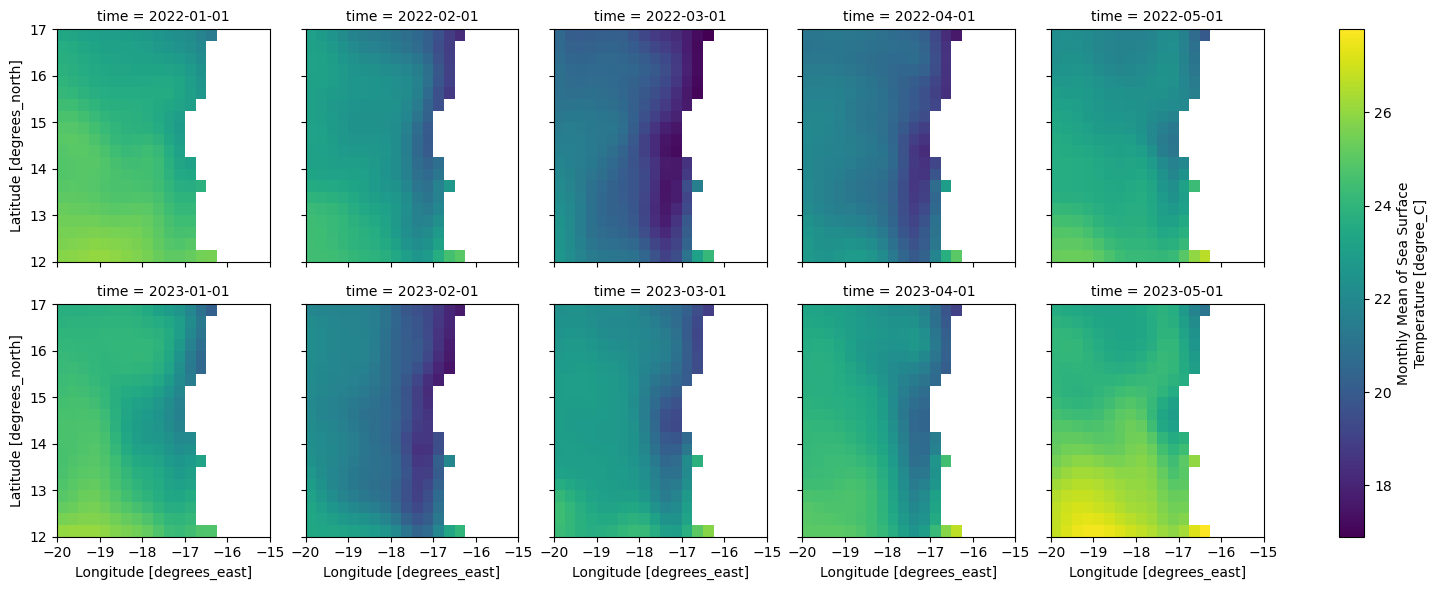

In [39]:
sst_rec.sel(time = NH_times).plot(x = "longitude", y = "latitude", col = "time", col_wrap=5)

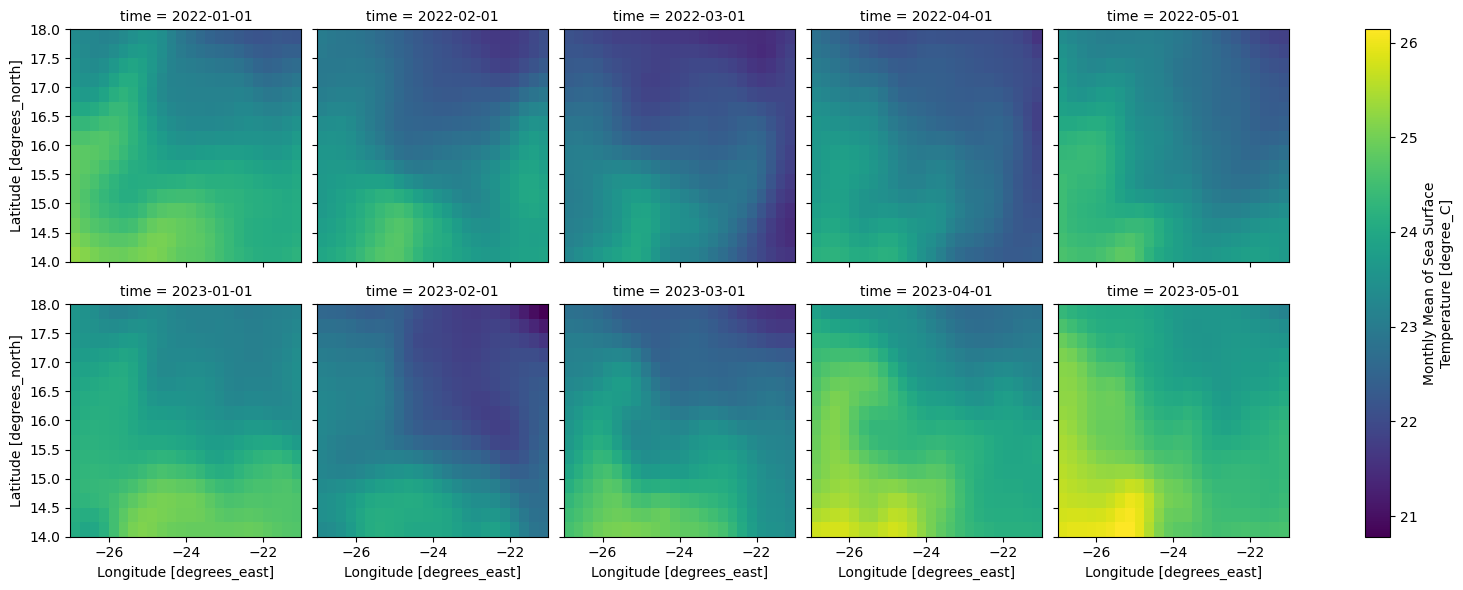

In [40]:
sst_cvi.sel(time = NH_times).plot(x = "longitude", y = "latitude", col = "time", col_wrap=5)

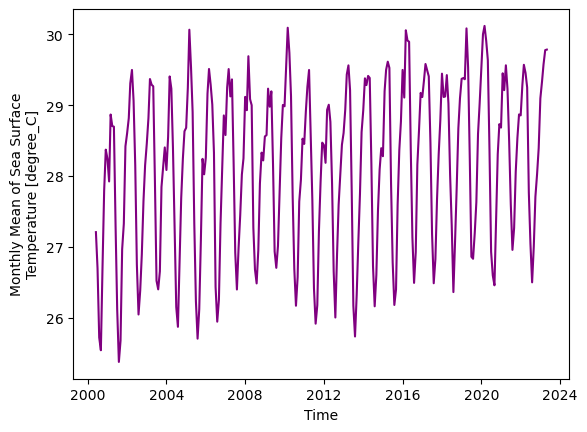

In [76]:
month_mean_ = ds_gog.mean(dim = ['latitude','longitude'])
#zero_line = month_means*0

# plot sst for particular time periods
t1 = '2000-06-01'; t2 = '2023-05-01'
fig, ax = plt.subplots()
month_means.sel(time = slice (t1, t2)).plot(color = "purple")
#zero_line.sel(time = slice(t1,t2)).plot(color = "black", linestyle = ":")

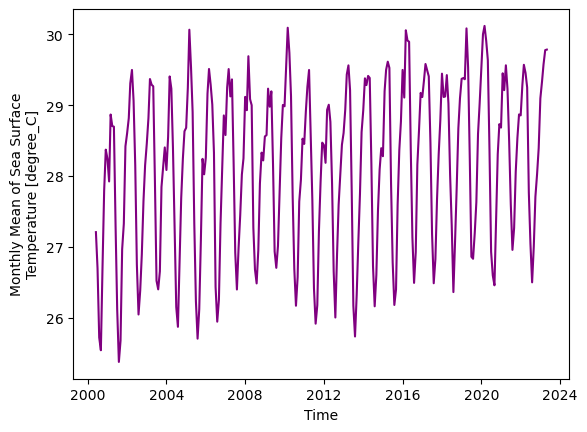

In [76]:
month_means = ds_gog.mean(dim = ['latitude','longitude'])
#zero_line = month_means*0

# plot sst for particular time periods
t1 = '2000-06-01'; t2 = '2023-05-01'
fig, ax = plt.subplots()
month_means.sel(time = slice (t1, t2)).plot(color = "purple")
#zero_line.sel(time = slice(t1,t2)).plot(color = "black", linestyle = ":")

In [78]:
month_means.sel(time = t1)

<xarray.DataArray 'sst' ()> Size: 4B
array(27.210806, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2000-06-01
Attributes: (12/13)
    actual_range:     [-1.8  32.14]
    colorBarMaximum:  32.0
    colorBarMinimum:  0.0
    ioos_category:    Temperature
    level_desc:       Surface
    long_name:        Monthly Mean of Sea Surface Temperature
    ...               ...
    precision:        2.0
    standard_name:    sea_surface_temperature
    statistic:        Monthly Mean
    units:            degree_C
    valid_range:      [-3. 45.]
    var_desc:         Sea Surface Temperature

In [42]:
yrs = (["2015-01-01","2015-12-01"],
      ["2016-01-01","2016-12-01"],
      ["2017-01-01","2017-12-01"],
      ["2018-01-01","2018-12-01"],
      ["2019-01-01","2019-12-01"],
      ["2020-01-01","2020-12-01"],
      ["2021-01-01","2021-12-01"],
      ["2022-01-01","2022-12-01"],
      ["2023-01-01","2023-12-01"],
      ["2024-01-01","2024-12-01"])

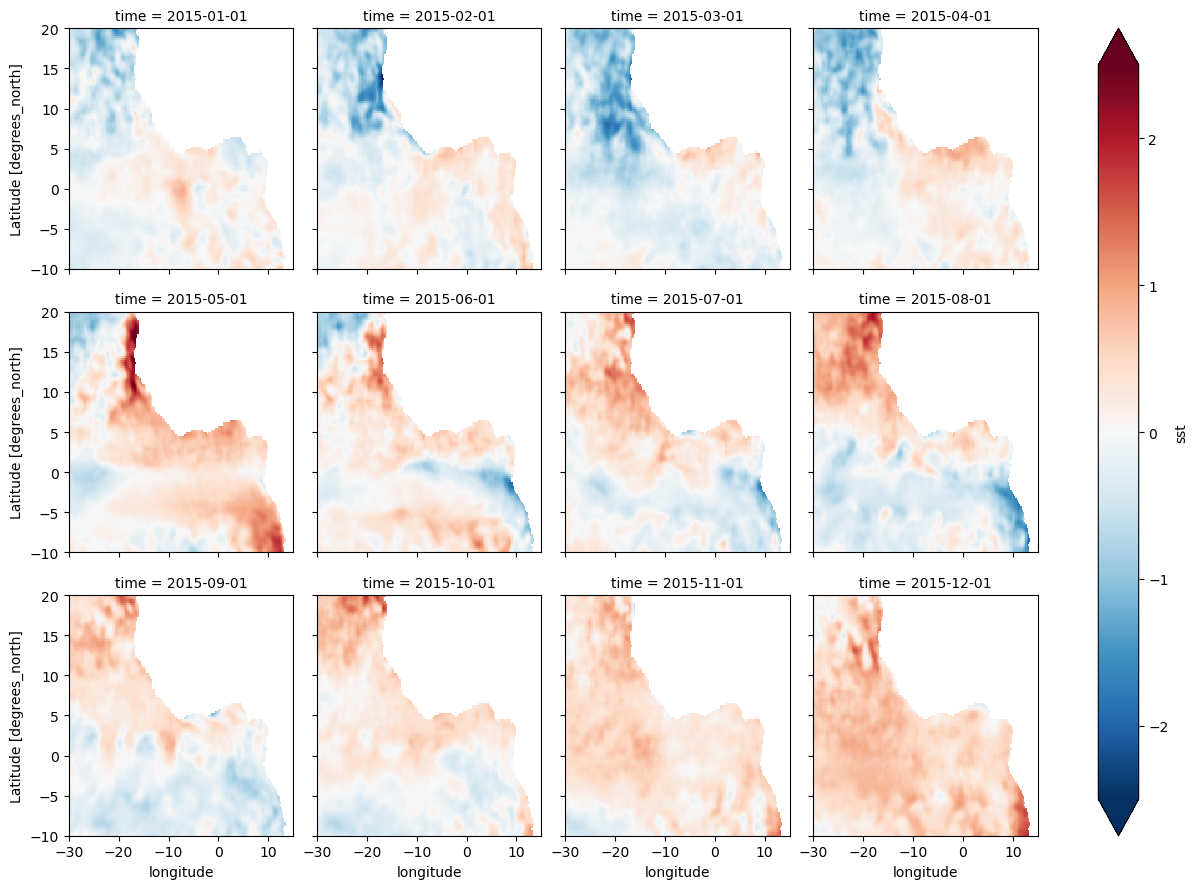

In [12]:
anom_spat.sel(time = slice(yrs[0][0],yrs[0][1])).plot(x = "longitude", y = "latitude", col = "time", col_wrap=4, cmap = colormap, vmin = -2.5, vmax = 2.5)

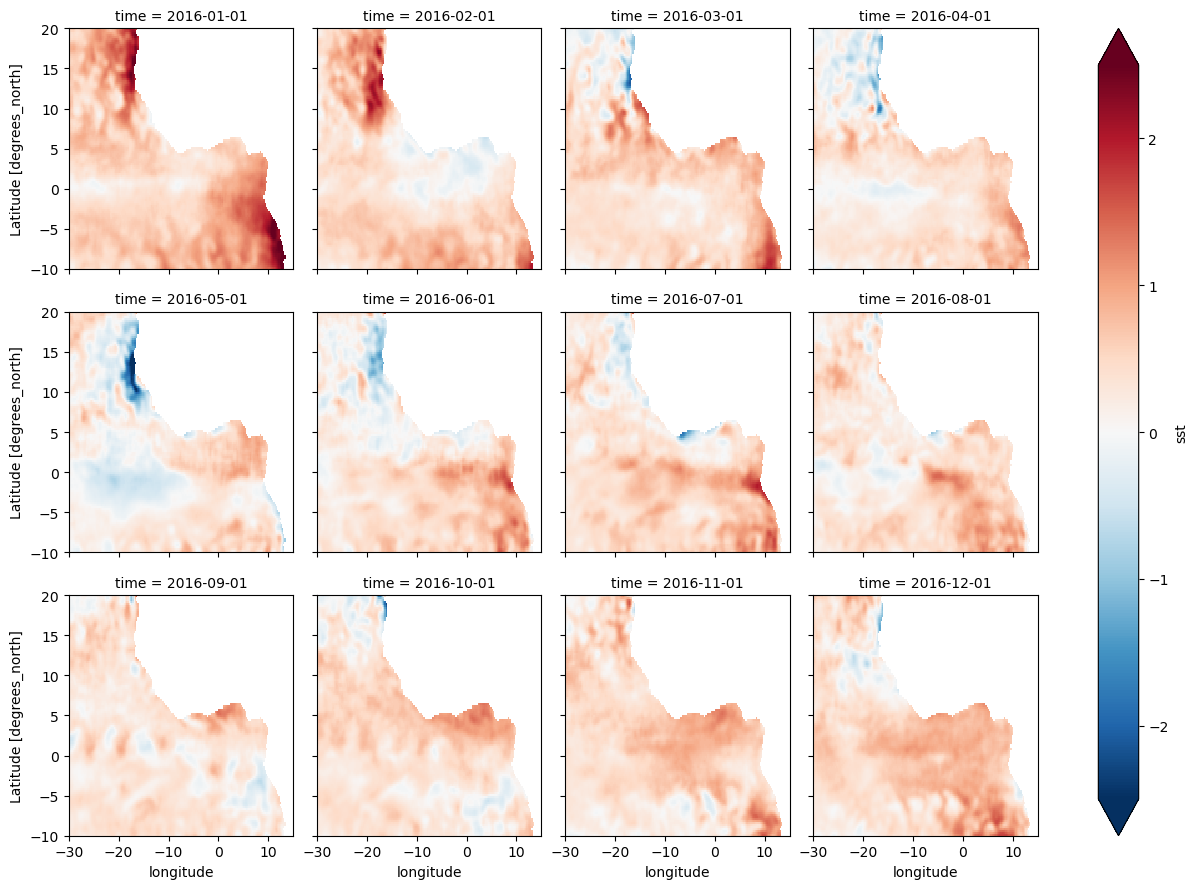

In [13]:
anom_spat.sel(time = slice(yrs[1][0],yrs[1][1])).plot(x = "longitude", y = "latitude", col = "time", col_wrap=4, cmap = colormap, vmin = -2.5, vmax = 2.5)

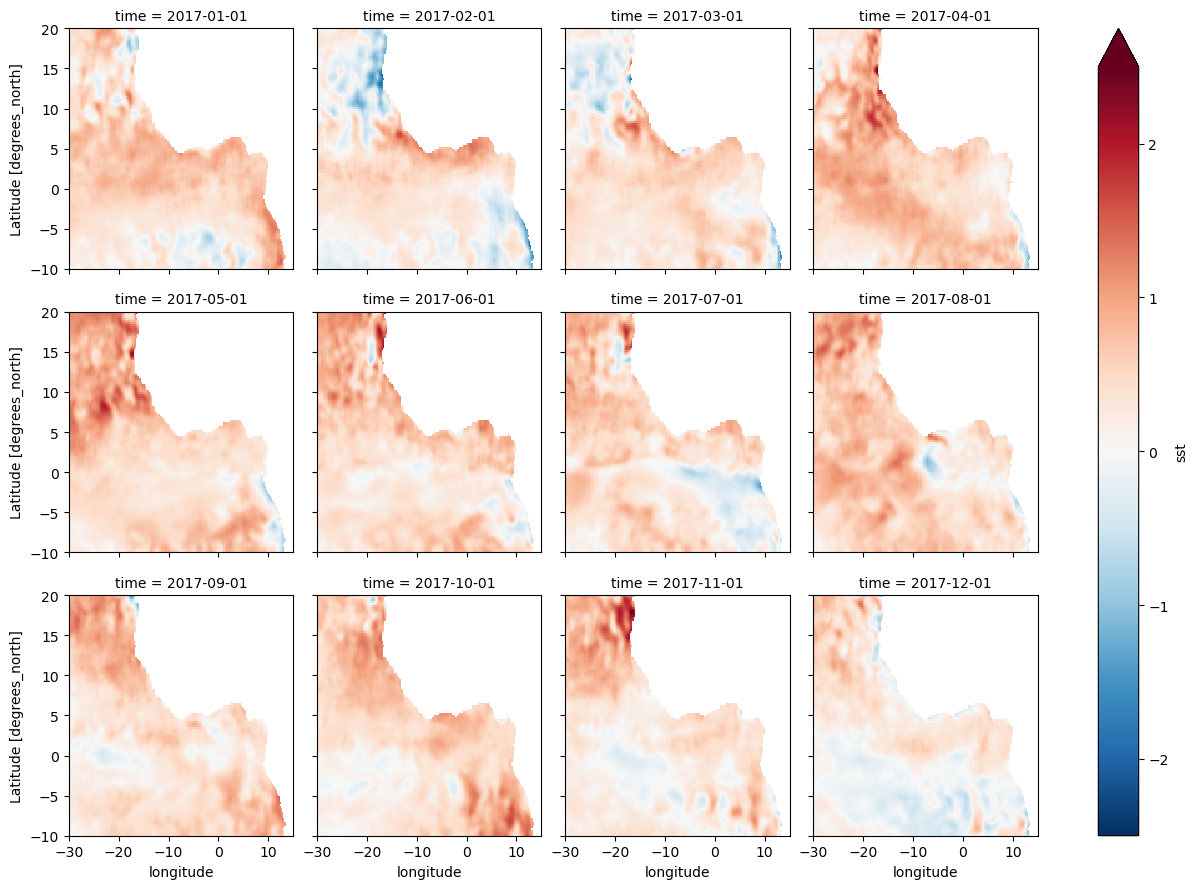

In [14]:
anom_spat.sel(time = slice(yrs[2][0],yrs[2][1])).plot(x = "longitude", y = "latitude", col = "time", col_wrap=4, cmap = colormap, vmin = -2.5, vmax = 2.5)

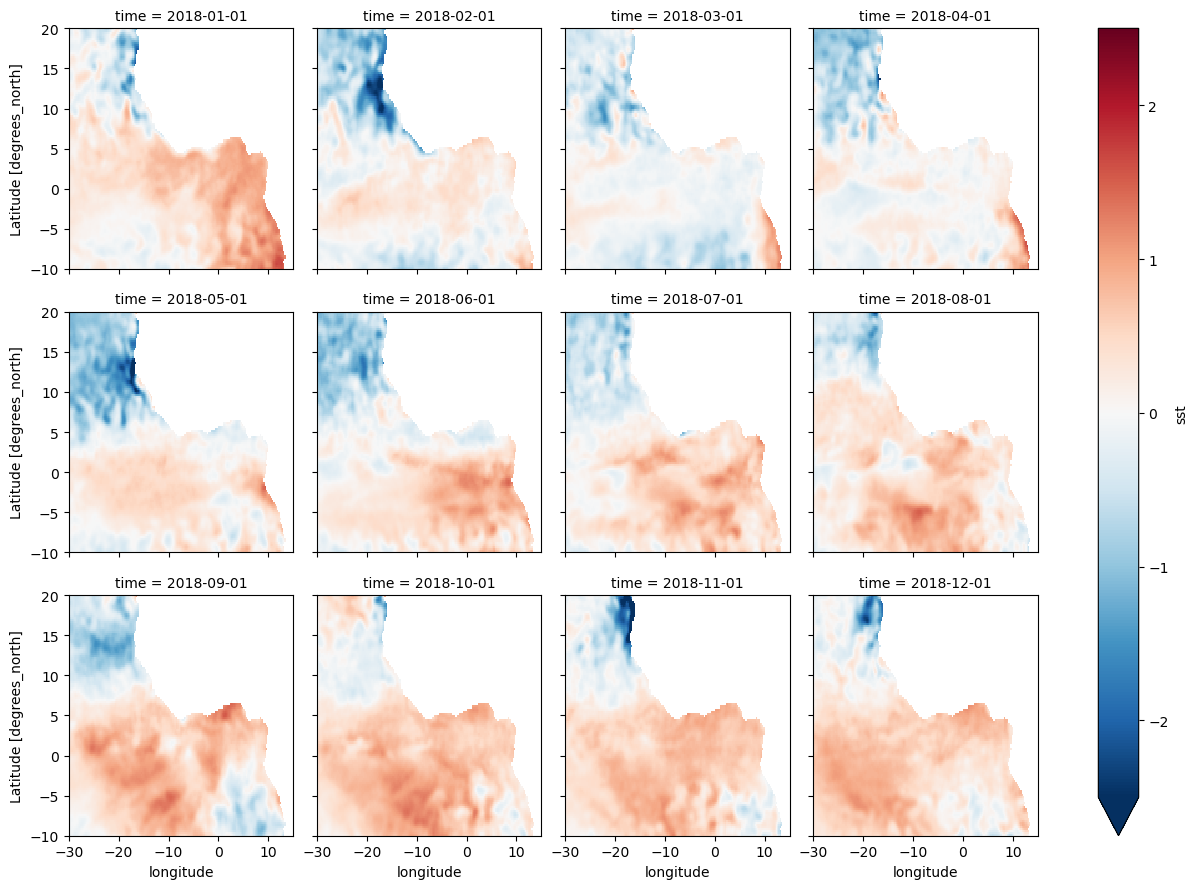

In [15]:
anom_spat.sel(time = slice(yrs[3][0],yrs[3][1])).plot(x = "longitude", y = "latitude", col = "time", col_wrap=4, cmap = colormap, vmin = -2.5, vmax = 2.5)

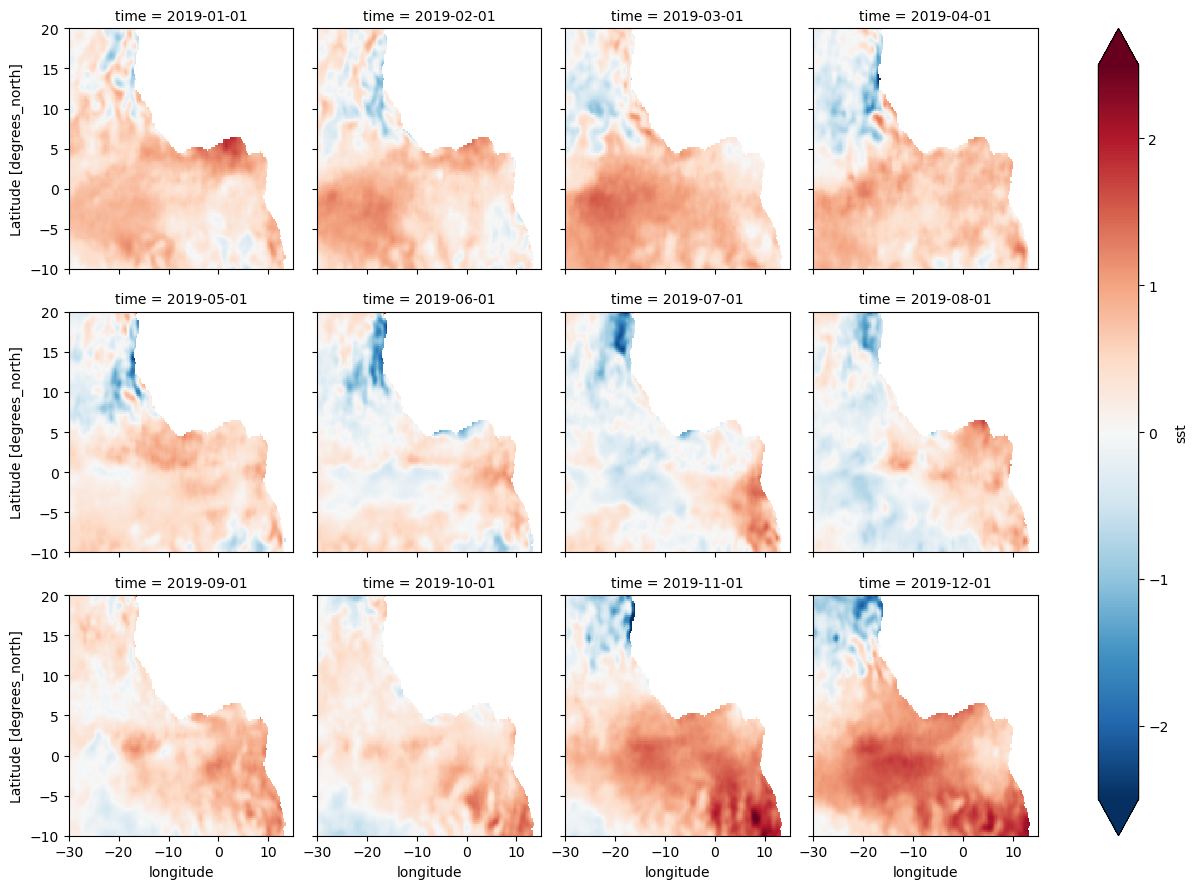

In [16]:
anom_spat.sel(time = slice(yrs[4][0],yrs[4][1])).plot(x = "longitude", y = "latitude", col = "time", col_wrap=4, cmap = colormap, vmin = -2.5, vmax = 2.5)

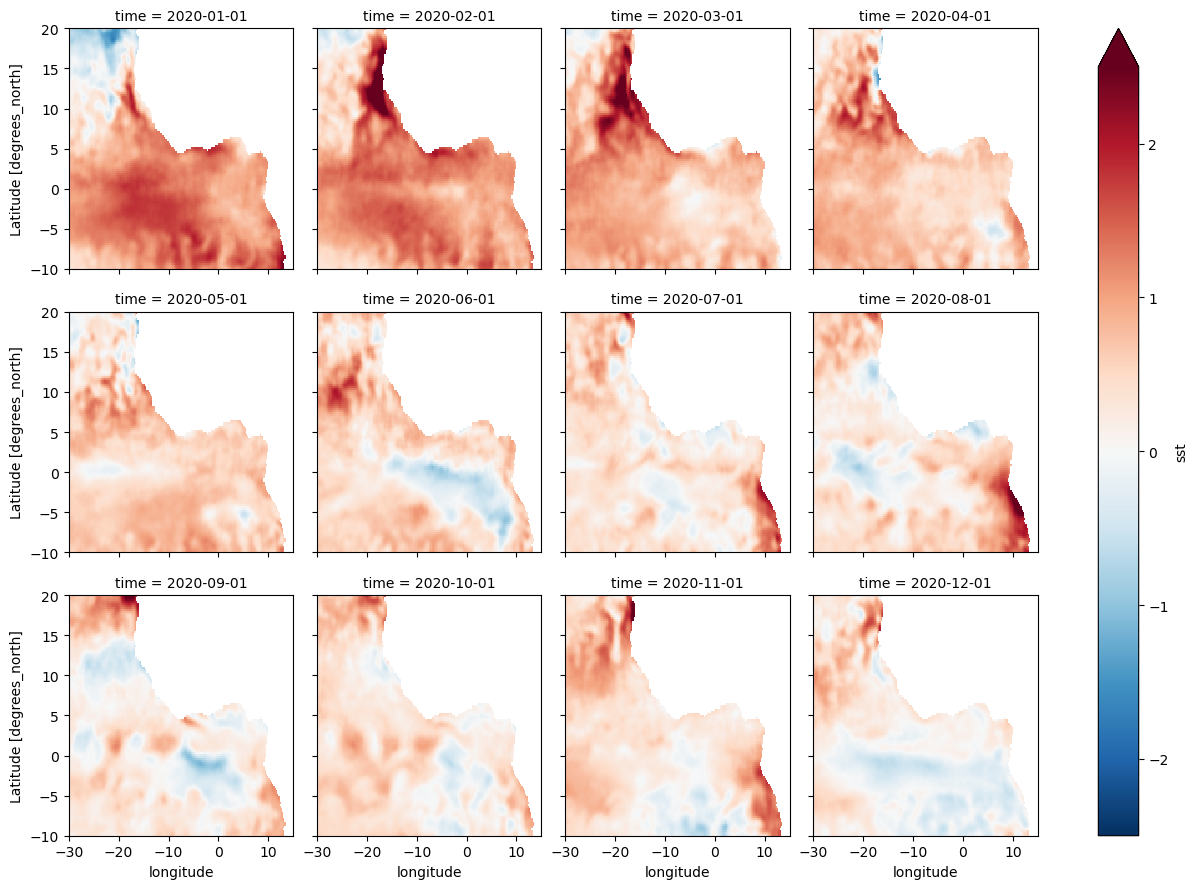

In [17]:
anom_spat.sel(time = slice(yrs[5][0],yrs[5][1])).plot(x = "longitude", y = "latitude", col = "time", col_wrap=4, cmap = colormap, vmin = -2.5, vmax = 2.5)

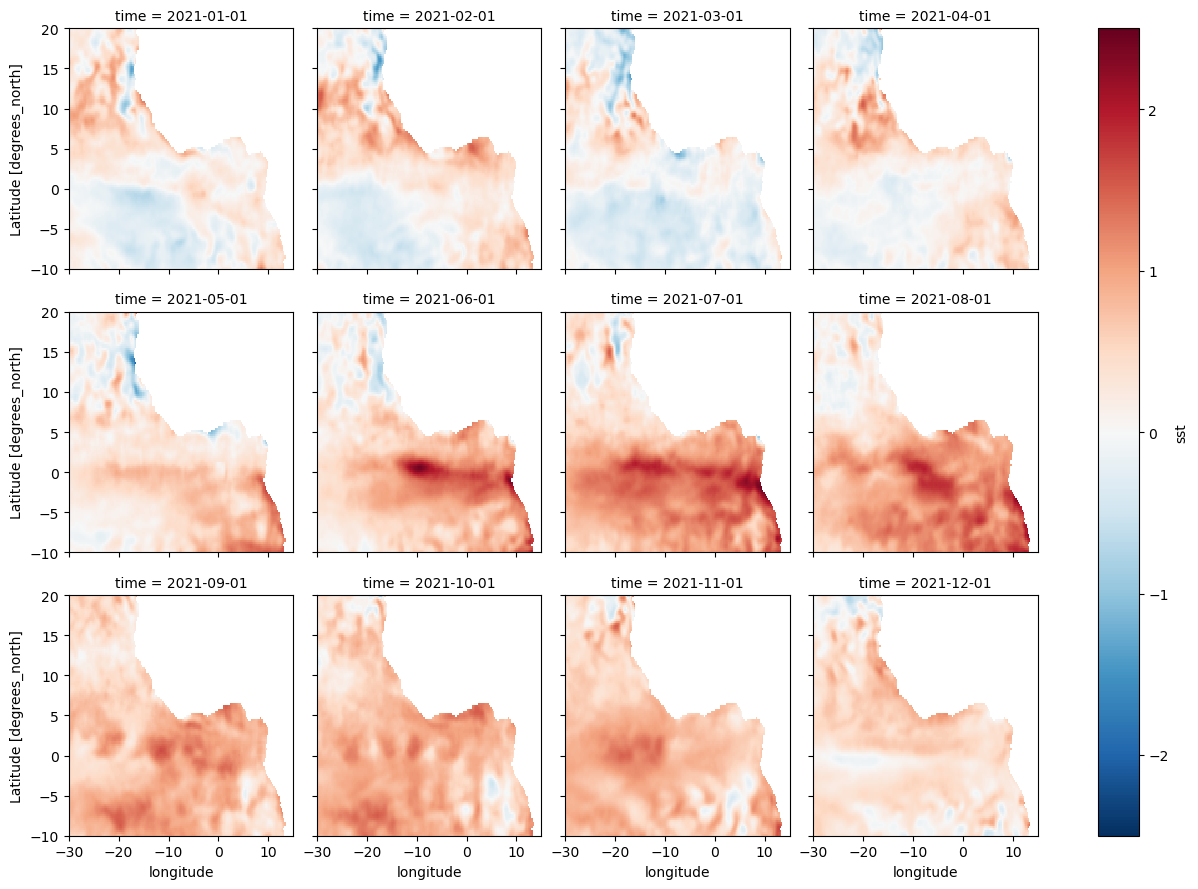

In [18]:
anom_spat.sel(time = slice(yrs[6][0],yrs[6][1])).plot(x = "longitude", y = "latitude", col = "time", col_wrap=4, cmap = colormap, vmin = -2.5, vmax = 2.5)

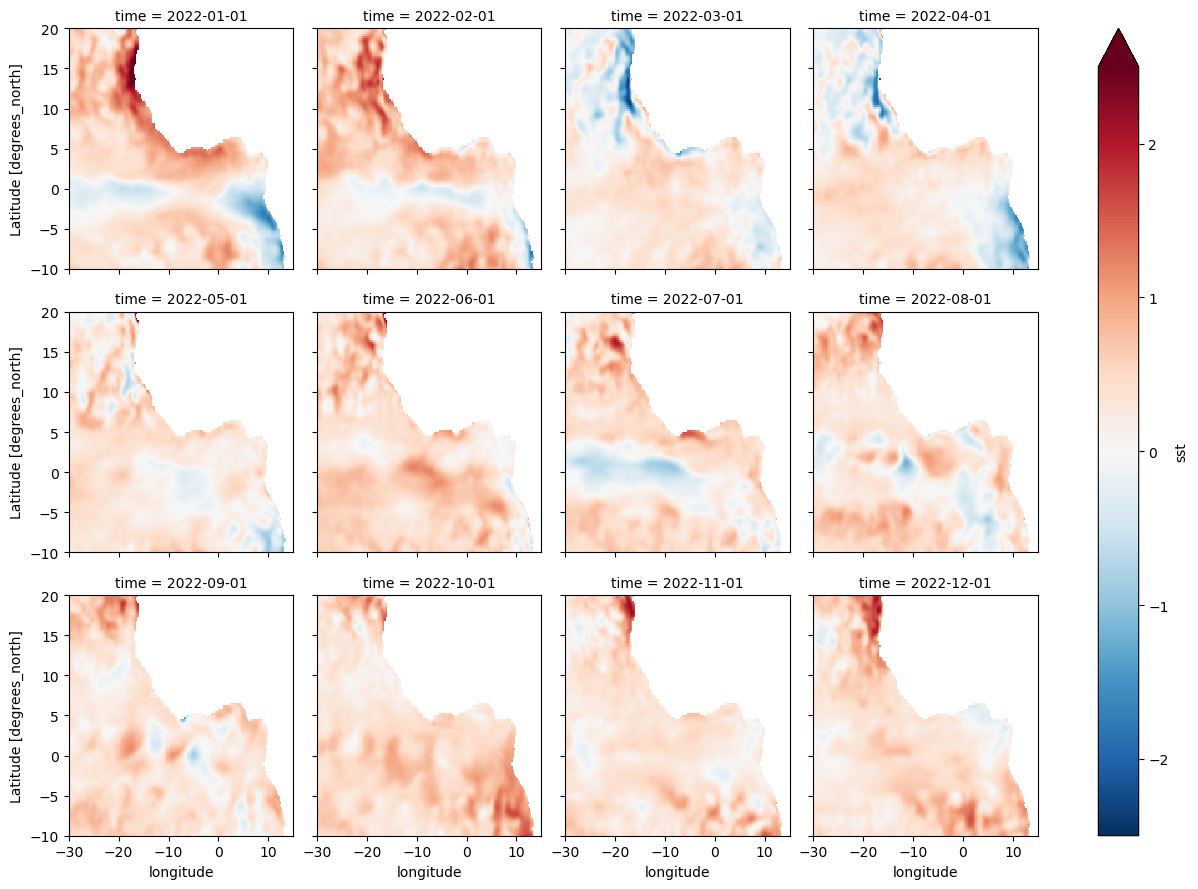

In [19]:
anom_spat.sel(time = slice(yrs[7][0],yrs[7][1])).plot(x = "longitude", y = "latitude", col = "time", col_wrap=4, cmap = colormap, vmin = -2.5, vmax = 2.5)

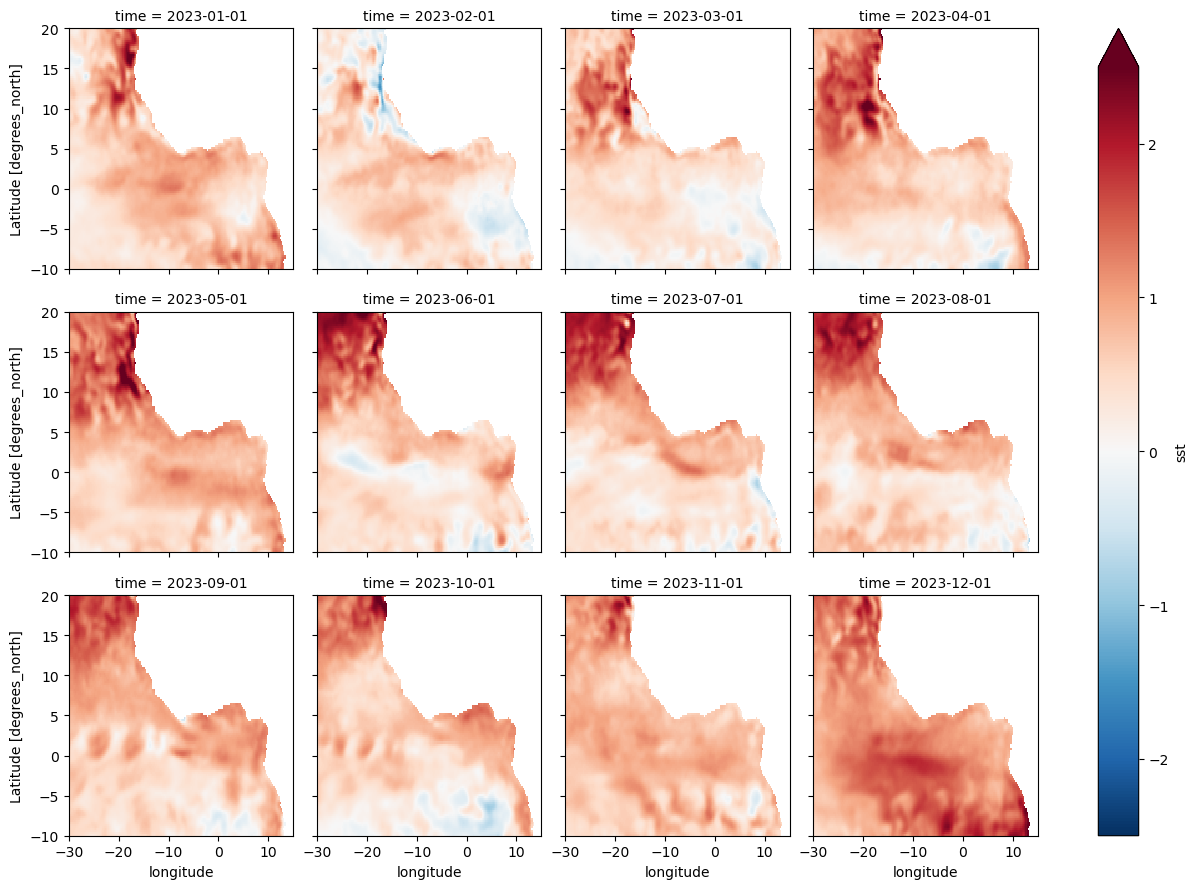

In [20]:
anom_spat.sel(time = slice(yrs[8][0],yrs[8][1])).plot(x = "longitude", y = "latitude", col = "time", col_wrap=4, cmap = colormap, vmin = -2.5, vmax = 2.5)

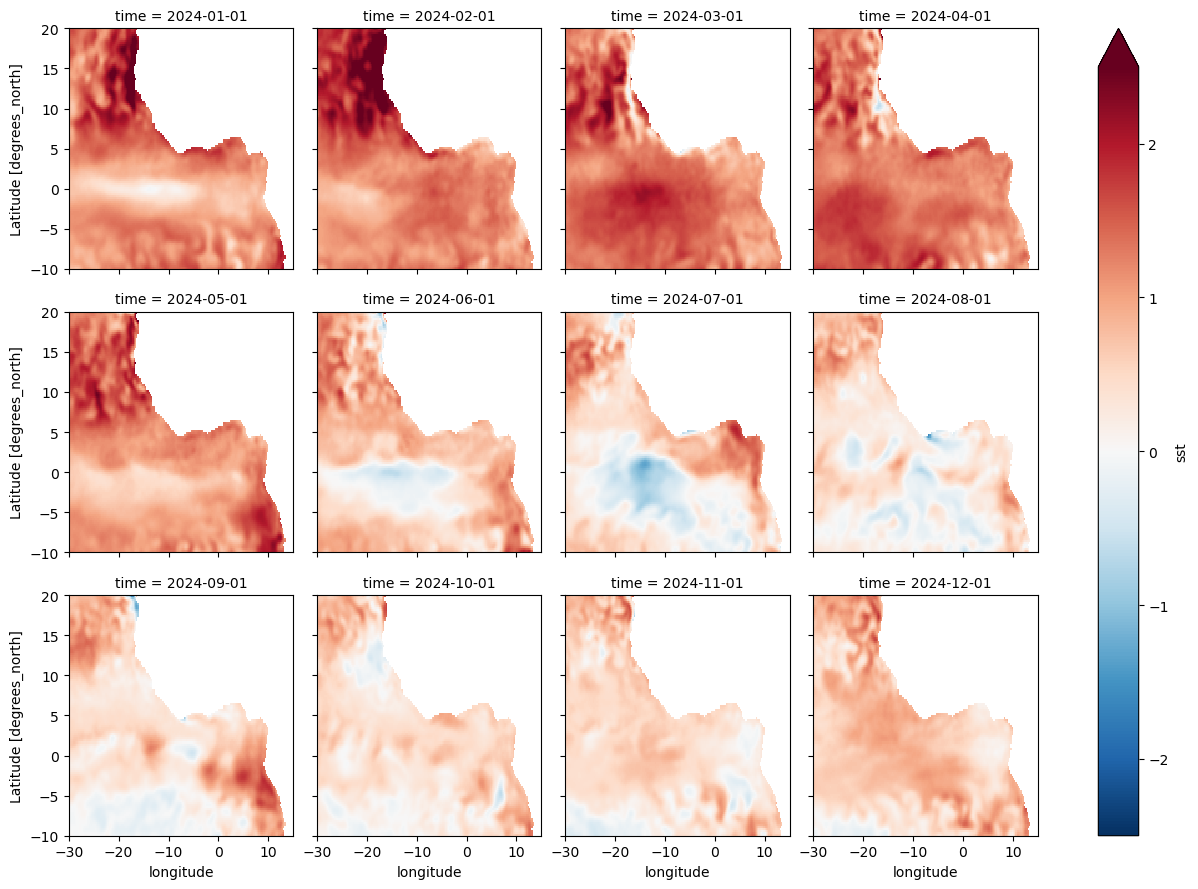

In [21]:
anom_spat.sel(time = slice(yrs[9][0],yrs[9][1])).plot(x = "longitude", y = "latitude", col = "time", col_wrap=4, cmap = colormap, vmin = -2.5, vmax = 2.5)

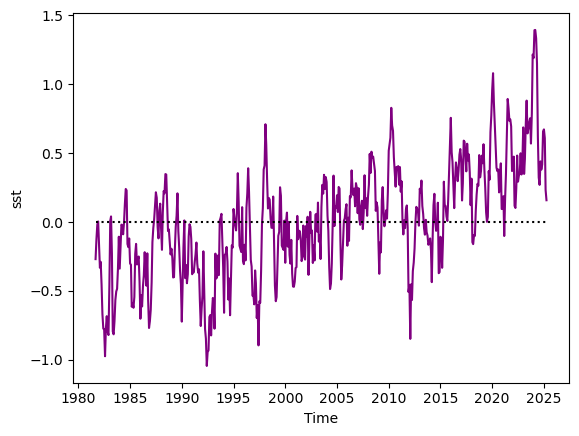

In [34]:
# plot full timeseries of monthly anomalies
month_anom_means = anom_spat.mean(dim = ['latitude','longitude'])
zero_line = month_anom_means*0

fig, ax = plt.subplots()
month_anom_means.plot(color="purple")
zero_line.plot(linestyle = ':', color = "k" )

## (zoom in) Calculate monthly anomaly means over space (2000-06 - 2023-05, and zero-line to show the mean

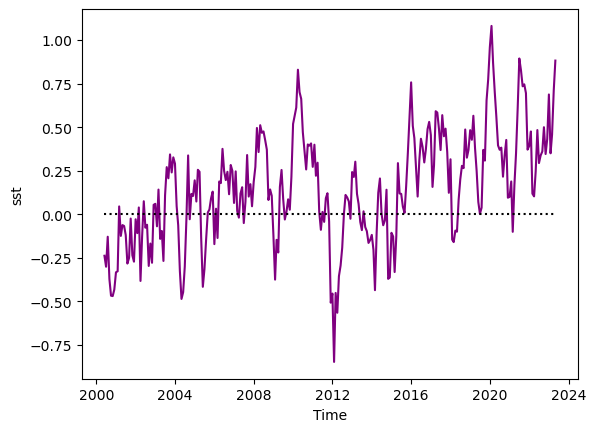

In [35]:
# plot sst anomalies just for the period of time when recorders were deployed
t1 = '2000-06-01'; t2 = '2023-05-01'

fig, ax = plt.subplots()
month_anom_means.sel(time = slice (t1, t2)).plot(color = "purple")
zero_line.sel(time = slice(t1,t2)).plot(color = "black", linestyle = ":")